# Section 07 — Evaluation

Every model in sections 01-05 was evaluated with HitRate@10 and NDCG@10. That's a start, but it's not the full story. This section builds the complete offline evaluation suite — **implemented from scratch** — and runs every model through it for a clean comparison.

## Why evaluation is hard

**Offline metrics** (NDCG, precision, recall) measure how well a model ranks items users historically interacted with. They're fast, reproducible, and essential during development. But they have known blind spots:
- They only measure what users **did** interact with — never what they **would have** but didn't see
- A perfectly serendipitous recommendation that the user would love scores 0 (not in test set)
- Popularity bias: popular items appear in most users' test sets, so models that push popular items look good offline

**Online metrics** (CTR, revenue, session length) are the actual ground truth — but require live traffic and A/B tests (section 08).

The metrics we'll compute:

| Metric | What it measures |
|---|---|
| Precision@K | Fraction of recommended items that are relevant |
| Recall@K | Fraction of relevant items that appear in top K |
| F1@K | Harmonic mean of precision and recall |
| NDCG@K | Ranking quality — relevant items ranked higher score better |
| MAP@K | Mean Average Precision — average precision across ranks |
| HitRate@K | Did the relevant item appear anywhere in top K? |
| MRR | Mean Reciprocal Rank — how high is the first relevant item? |
| Coverage | What fraction of items the system ever recommends |
| Diversity (ILD) | How different are items within a recommendation list? |
| Serendipity | Unexpected + relevant items (surprise) |
| Popularity Bias | Are recommendations skewed toward popular items? |

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Load Data

In [2]:
DATA_PATH  = '../data/ml-100k/u.data'
ITEM_PATH  = '../data/ml-100k/u.item'
GENRE_PATH = '../data/ml-100k/u.genre'

ratings = pd.read_csv(DATA_PATH, sep='\t', header=None,
                      names=['user_id', 'item_id', 'rating', 'timestamp'])
ratings['user_idx'] = ratings['user_id'] - 1
ratings['item_idx'] = ratings['item_id'] - 1

N_USERS = ratings['user_idx'].max() + 1
N_ITEMS = ratings['item_idx'].max() + 1

# LOO split
ratings_sorted = ratings.sort_values('timestamp')
test_set = ratings_sorted.groupby('user_idx').last().reset_index()[['user_idx', 'item_idx']]
test_dict = dict(zip(test_set['user_idx'], test_set['item_idx']))
test_pairs = set(zip(test_set['user_idx'], test_set['item_idx']))
train_df = ratings[~ratings.apply(lambda r: (r['user_idx'], r['item_idx']) in test_pairs, axis=1)].copy()

# Interaction matrix
R = np.zeros((N_USERS, N_ITEMS), dtype=np.float32)
for _, row in train_df.iterrows():
    R[int(row['user_idx']), int(row['item_idx'])] = row['rating']

user_rated = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()
for u, ti in test_dict.items():
    user_rated.setdefault(u, set()).add(ti)

# Item popularity (train)
item_counts = train_df.groupby('item_idx').size().reindex(range(N_ITEMS), fill_value=0)
item_popularity = item_counts.values.astype(float)

# Item genre features (for diversity computation)
genre_cols_df = pd.read_csv(ITEM_PATH, sep='|', encoding='latin-1', header=None,
                             usecols=list(range(5, 24)))
genre_matrix = genre_cols_df.values.astype(float)
gnorms = np.linalg.norm(genre_matrix, axis=1, keepdims=True)
gnorms[gnorms == 0] = 1e-10
genre_matrix_norm = genre_matrix / gnorms

print(f'Users: {N_USERS}, Items: {N_ITEMS}, Train: {len(train_df)}, Test: {len(test_dict)}')

Users: 943, Items: 1682, Train: 99057, Test: 943


## Metric Implementations (from scratch)

In [3]:
# ─── Ranking quality metrics ───────────────────────────────────────────────

def precision_at_k(recommended, relevant, k):
    """Fraction of top-K recommendations that are relevant."""
    top_k = set(recommended[:k])
    return len(top_k & set(relevant)) / k


def recall_at_k(recommended, relevant, k):
    """Fraction of relevant items that appear in top-K."""
    if not relevant:
        return 0.0
    top_k = set(recommended[:k])
    return len(top_k & set(relevant)) / len(relevant)


def f1_at_k(recommended, relevant, k):
    p = precision_at_k(recommended, relevant, k)
    r = recall_at_k(recommended, relevant, k)
    return 2 * p * r / (p + r + 1e-10)


def ndcg_at_k(recommended, relevant, k):
    """Normalized Discounted Cumulative Gain @K.
    
    DCG = Σ rel_i / log2(i+1)  for i in 1..k
    NDCG = DCG / IDCG  where IDCG is DCG for perfect ranking
    """
    relevant_set = set(relevant)
    dcg = sum(
        1.0 / np.log2(i + 2)
        for i, item in enumerate(recommended[:k])
        if item in relevant_set
    )
    # Ideal DCG: all relevant items at the top
    n_rel = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(n_rel))
    return dcg / idcg if idcg > 0 else 0.0


def average_precision_at_k(recommended, relevant, k):
    """Average precision for a single query."""
    relevant_set = set(relevant)
    hits, sum_prec = 0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant_set:
            hits += 1
            sum_prec += hits / (i + 1)
    return sum_prec / min(len(relevant), k) if relevant else 0.0


def hit_rate_at_k(recommended, relevant, k):
    """1 if any relevant item is in top-K, else 0."""
    return int(bool(set(recommended[:k]) & set(relevant)))


def reciprocal_rank(recommended, relevant):
    """1/rank of first relevant item. 0 if none found."""
    relevant_set = set(relevant)
    for i, item in enumerate(recommended):
        if item in relevant_set:
            return 1.0 / (i + 1)
    return 0.0


# ─── Beyond-accuracy metrics ───────────────────────────────────────────────

def catalog_coverage(all_recommendations, n_items):
    """Fraction of all items that appear in at least one recommendation list."""
    unique_recommended = set(item for rec_list in all_recommendations for item in rec_list)
    return len(unique_recommended) / n_items


def intra_list_diversity(recommended_items, item_features):
    """Average pairwise dissimilarity within a recommendation list.
    
    Uses 1 - cosine_similarity between item genre vectors.
    High ILD = more diverse recommendations.
    """
    if len(recommended_items) < 2:
        return 0.0
    vecs = item_features[recommended_items]  # (k, d)
    sim_matrix = vecs @ vecs.T               # (k, k) cosine similarities
    # Average pairwise distance (excluding diagonal)
    k = len(recommended_items)
    total_dissim = np.sum(1 - sim_matrix) - k  # subtract diagonal (1-1=0 each)
    n_pairs = k * (k - 1)
    return total_dissim / n_pairs


def serendipity_at_k(recommended, relevant, item_popularity, k, pop_threshold=0.1):
    """Fraction of top-K recommendations that are both relevant AND non-obvious.
    
    'Non-obvious' here means the item is not in the top pop_threshold of the catalog.
    """
    top_k = recommended[:k]
    relevant_set = set(relevant)
    n_popular = int(len(item_popularity) * pop_threshold)
    popular_items = set(np.argpartition(item_popularity, -n_popular)[-n_popular:])
    # Serendipitous = relevant AND not popular
    serendipitous = [i for i in top_k if i in relevant_set and i not in popular_items]
    return len(serendipitous) / k


def popularity_bias(all_recommendations, item_popularity):
    """Average popularity of recommended items (normalized to [0,1]).
    
    High = model recommends mostly popular items (bad for long-tail coverage).
    """
    pop_norm = item_popularity / item_popularity.max()
    pops = [pop_norm[item] for rec in all_recommendations for item in rec]
    return np.mean(pops) if pops else 0.0


print('All metric functions defined.')

All metric functions defined.


## Build All Models

In [4]:
# ── Model 1: Popularity ──────────────────────────────────────────────────────

pop_scores_raw = item_popularity.copy()


# ── Model 2: User-User CF ────────────────────────────────────────────────────

print('Computing User-User CF similarities...')
norms = np.linalg.norm(R, axis=1, keepdims=True)
norms[norms == 0] = 1e-10
R_normed = R / norms
user_sim = R_normed @ R_normed.T

user_means = np.where(R > 0, R, np.nan)
user_means = np.nanmean(user_means, axis=1)  # (N_USERS,)
user_means = np.nan_to_num(user_means, nan=3.0)
R_centered = R - user_means[:, None]
R_centered[R == 0] = 0.0

def uu_cf_scores(user_idx, K=30):
    sims = user_sim[user_idx].copy()
    sims[user_idx] = 0.0  # exclude self
    top_k = np.argpartition(sims, -K)[-K:]
    mask = np.zeros(N_USERS, dtype=bool)
    mask[top_k] = True
    sims = np.where(mask & (sims > 0), sims, 0.0)
    denom = np.abs(sims).sum() + 1e-10
    return np.clip(user_means[user_idx] + (sims @ R_centered) / denom, 1, 5)

print('User-User CF ready.')

Computing User-User CF similarities...
User-User CF ready.


In [5]:
# ── Model 3: Content-Based ───────────────────────────────────────────────────

print('Building content features...')

items_df = pd.read_csv(ITEM_PATH, sep='|', encoding='latin-1', header=None,
                       usecols=[0, 1], names=['item_id', 'title'])

def tokenize(title):
    title = re.sub(r'\(\d{4}\)', '', title)
    title = re.sub(r'[^a-z\s]', '', title.lower())
    stopwords = {'the', 'a', 'an', 'of', 'in', 'and', 'to', 'is', 'it', 's'}
    return [w for w in title.split() if w and w not in stopwords]

token_lists = [tokenize(t) for t in items_df['title']]
vocab = sorted(set(w for tl in token_lists for w in tl))
word2idx = {w: i for i, w in enumerate(vocab)}

TF = np.zeros((N_ITEMS, len(vocab)))
for i, tokens in enumerate(token_lists):
    for w in tokens:
        TF[i, word2idx[w]] += 1
    if len(tokens) > 0:
        TF[i] /= len(tokens)

DF = (TF > 0).sum(axis=0)
IDF = np.log((N_ITEMS + 1) / (DF + 1)) + 1
TFIDF = TF * IDF

item_features = np.hstack([genre_matrix, TFIDF])
fn = np.linalg.norm(item_features, axis=1, keepdims=True)
fn[fn == 0] = 1e-10
item_features_norm = item_features / fn

def build_user_profile(user_idx):
    rated_mask = R[user_idx] > 0
    if rated_mask.sum() == 0:
        return None
    mean_r = R[user_idx][rated_mask].mean()
    weights = np.where(rated_mask, R[user_idx] - mean_r, 0.0)
    profile = weights @ item_features_norm
    return profile / (np.abs(weights).sum() + 1e-10)

def cb_scores(user_idx):
    profile = build_user_profile(user_idx)
    if profile is None:
        return np.zeros(N_ITEMS)
    norm = np.linalg.norm(profile)
    return item_features_norm @ (profile / (norm + 1e-10))

print('Content-Based ready.')

Building content features...
Content-Based ready.


In [6]:
# ── Model 4: Implicit ALS ────────────────────────────────────────────────────

print('Training Implicit ALS...')

class ImplicitALS:
    def __init__(self, n_factors=50, n_iters=15, reg=0.01, alpha=40):
        self.n_factors = n_factors; self.n_iters = n_iters
        self.reg = reg; self.alpha = alpha
        self.P = self.Q = None

    def fit(self, R):
        n_users, n_items = R.shape
        C = 1.0 + self.alpha * R
        Pref = (R > 0).astype(float)
        rng = np.random.default_rng(42)
        self.P = rng.normal(0, 0.01, (n_users, self.n_factors))
        self.Q = rng.normal(0, 0.01, (n_items, self.n_factors))
        regI = self.reg * np.eye(self.n_factors)
        for it in range(self.n_iters):
            QTQ = self.Q.T @ self.Q
            for u in range(n_users):
                QTCuQ = QTQ + self.Q.T @ ((C[u] - 1)[:, None] * self.Q)
                self.P[u] = np.linalg.solve(QTCuQ + regI, self.Q.T @ (C[u] * Pref[u]))
            PTtP = self.P.T @ self.P
            for i in range(n_items):
                c_i = C[:, i]
                PTCiP = PTtP + self.P.T @ ((c_i - 1)[:, None] * self.P)
                self.Q[i] = np.linalg.solve(PTCiP + regI, self.P.T @ (c_i * Pref[:, i]))
            if (it + 1) % 5 == 0:
                print(f'  ALS iter {it+1}/{self.n_iters}')
        return self

    def score_all_items(self, u):
        return self.P[u] @ self.Q.T


als = ImplicitALS(n_factors=50, n_iters=15, reg=0.01, alpha=40)
als.fit(R)
print('ALS done.')

Training Implicit ALS...


  ALS iter 5/15


  ALS iter 10/15


  ALS iter 15/15
ALS done.


## Full Evaluation Runner

Compute all metrics for a given scoring function. For LOO evaluation, each user has exactly one relevant item (their held-out test item), but we also allow multi-item relevance to support the beyond-accuracy metrics.

In [7]:
def get_top_k_recommendations(scores_fn, user_idx, k=10):
    """Return top-K items for a user, excluding already-rated items."""
    scores = scores_fn(user_idx).copy()
    rated_train = user_rated.get(user_idx, set()) - {test_dict.get(user_idx, -1)}
    scores[list(rated_train)] = -np.inf
    top_k = np.argsort(scores)[::-1][:k]
    return top_k.tolist()


def full_evaluation(scores_fn, model_name, k=10):
    """Run all metrics for a model."""
    prec, rec, f1, ndcg, ap, hr, rr, div, ser = [], [], [], [], [], [], [], [], []
    all_recs = []
    
    for user_idx, test_item in test_dict.items():
        relevant = [test_item]  # LOO: one relevant item per user
        recommended = get_top_k_recommendations(scores_fn, user_idx, k)
        all_recs.append(recommended)
        
        prec.append(precision_at_k(recommended, relevant, k))
        rec.append(recall_at_k(recommended, relevant, k))
        f1.append(f1_at_k(recommended, relevant, k))
        ndcg.append(ndcg_at_k(recommended, relevant, k))
        ap.append(average_precision_at_k(recommended, relevant, k))
        hr.append(hit_rate_at_k(recommended, relevant, k))
        rr.append(reciprocal_rank(recommended, relevant))
        div.append(intra_list_diversity(recommended, genre_matrix_norm))
        ser.append(serendipity_at_k(recommended, relevant, item_popularity, k))
    
    cov  = catalog_coverage(all_recs, N_ITEMS)
    pbias = popularity_bias(all_recs, item_popularity)
    
    return {
        'model': model_name,
        f'Precision@{k}': np.mean(prec),
        f'Recall@{k}':    np.mean(rec),
        f'F1@{k}':        np.mean(f1),
        f'NDCG@{k}':      np.mean(ndcg),
        f'MAP@{k}':       np.mean(ap),
        f'HitRate@{k}':   np.mean(hr),
        'MRR':            np.mean(rr),
        'Coverage':       cov,
        'Diversity(ILD)': np.mean(div),
        'Serendipity':    np.mean(ser),
        'PopBias':        pbias,
    }

print('Evaluation runner ready.')

Evaluation runner ready.


In [8]:
K = 10
print(f'Evaluating all models at K={K}...')

models = [
    ('Popularity',      lambda u: pop_scores_raw),
    ('User-User CF',    uu_cf_scores),
    ('Content-Based',   cb_scores),
    ('Implicit ALS',    als.score_all_items),
]

all_results = []
for name, fn in models:
    print(f'  {name}...')
    result = full_evaluation(fn, name, k=K)
    all_results.append(result)
    print(f'    HitRate@{K}={result[f"HitRate@{K}"]:.4f}  '
          f'NDCG@{K}={result[f"NDCG@{K}"]:.4f}  '
          f'Coverage={result["Coverage"]:.3f}  '
          f'Diversity={result["Diversity(ILD)"]:.4f}')

results_df = pd.DataFrame(all_results).set_index('model')

Evaluating all models at K=10...
  Popularity...
    HitRate@10=0.0785  NDCG@10=0.0379  Coverage=0.054  Diversity=0.6315
  User-User CF...


    HitRate@10=0.0742  NDCG@10=0.0355  Coverage=0.215  Diversity=0.5770
  Content-Based...


    HitRate@10=0.0212  NDCG@10=0.0120  Coverage=0.472  Diversity=0.3578
  Implicit ALS...
    HitRate@10=0.1007  NDCG@10=0.0453  Coverage=0.542  Diversity=0.6129


## Results: Full Metrics Table

In [9]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(results_df.to_string())

               Precision@10  Recall@10  F1@10  NDCG@10  MAP@10  HitRate@10    MRR  Coverage  Diversity(ILD)  Serendipity  PopBias
model                                                                                                                            
Popularity           0.0078     0.0785 0.0143   0.0379  0.0256      0.0785 0.0256    0.0541          0.6315       0.0000   0.7222
User-User CF         0.0074     0.0742 0.0135   0.0355  0.0240      0.0742 0.0240    0.2146          0.5770       0.0014   0.4309
Content-Based        0.0021     0.0212 0.0039   0.0120  0.0093      0.0212 0.0093    0.4721          0.3578       0.0014   0.1020
Implicit ALS         0.0101     0.1007 0.0183   0.0453  0.0288      0.1007 0.0288    0.5422          0.6129       0.0043   0.3085


## Metric-by-Metric Visualization

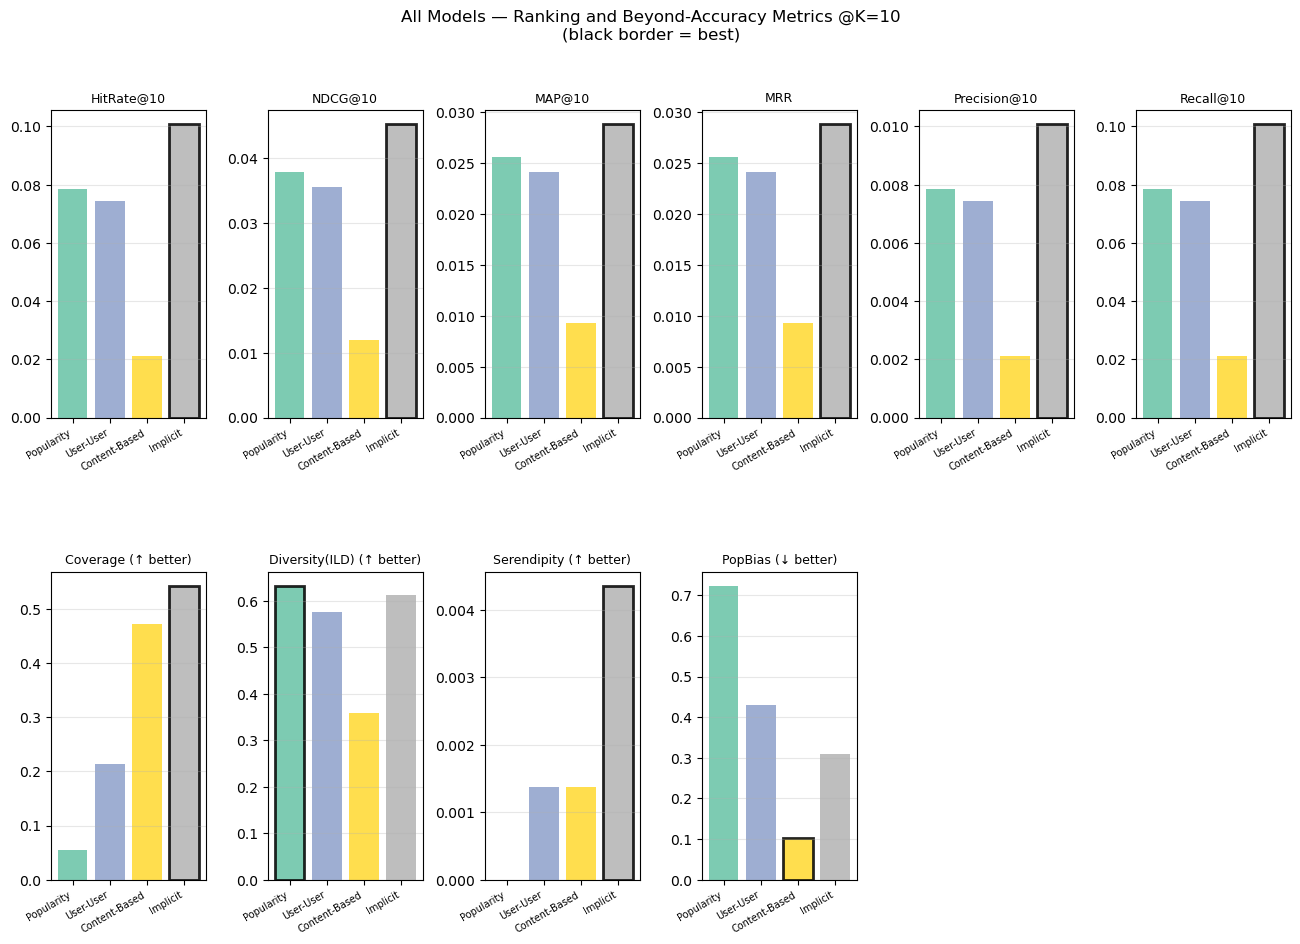

In [10]:
ranking_metrics = [f'HitRate@{K}', f'NDCG@{K}', f'MAP@{K}', 'MRR', f'Precision@{K}', f'Recall@{K}']
beyond_metrics  = ['Coverage', 'Diversity(ILD)', 'Serendipity', 'PopBias']

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.5, wspace=0.4)

model_names = results_df.index.tolist()
colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

# Top row: ranking metrics
for idx, metric in enumerate(ranking_metrics):
    ax = fig.add_subplot(gs[0, idx])
    vals = results_df[metric].values
    bars = ax.bar(range(len(model_names)), vals, color=colors, alpha=0.85)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([n.split()[0] for n in model_names], rotation=30, ha='right', fontsize=7)
    ax.set_title(metric, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    # Annotate best
    best_idx = np.argmax(vals)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

# Bottom row: beyond-accuracy metrics
for idx, metric in enumerate(beyond_metrics):
    ax = fig.add_subplot(gs[1, idx])
    vals = results_df[metric].values
    # For PopBias, lower is better
    bars = ax.bar(range(len(model_names)), vals, color=colors, alpha=0.85)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([n.split()[0] for n in model_names], rotation=30, ha='right', fontsize=7)
    ax.set_title(metric + (' (↓ better)' if metric == 'PopBias' else ' (↑ better)'), fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    best_idx = np.argmin(vals) if metric == 'PopBias' else np.argmax(vals)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

fig.suptitle(f'All Models — Ranking and Beyond-Accuracy Metrics @K={K}\n(black border = best)', fontsize=12)
plt.savefig('full_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

## Metric Correlations: Does Better NDCG Mean Better Diversity?

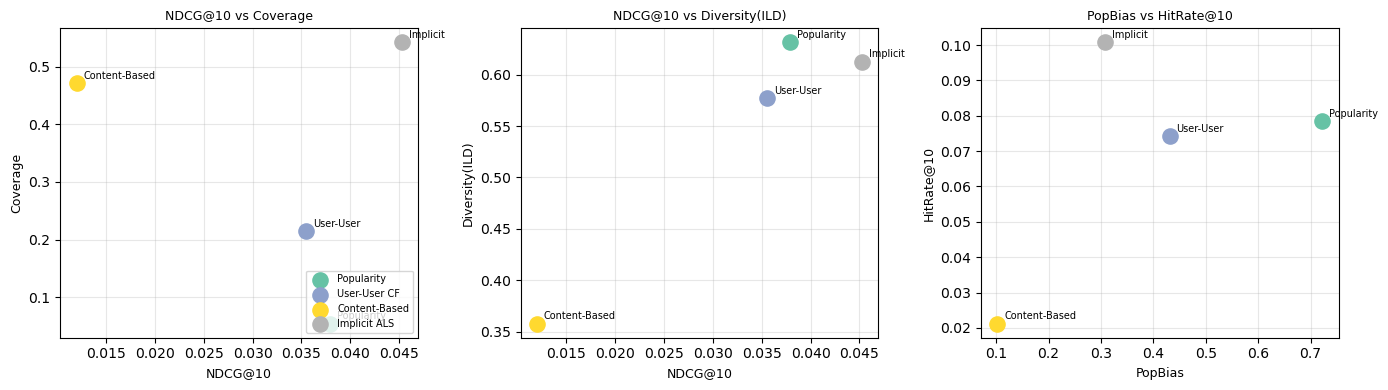

In [11]:
# Scatter: NDCG vs Coverage and NDCG vs Diversity
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_pairs = [
    (f'NDCG@{K}', 'Coverage'),
    (f'NDCG@{K}', 'Diversity(ILD)'),
    ('PopBias', f'HitRate@{K}'),
]

for ax, (x_col, y_col) in zip(axes, plot_pairs):
    for i, model in enumerate(model_names):
        ax.scatter(results_df.loc[model, x_col], results_df.loc[model, y_col],
                   s=120, color=colors[i], zorder=3, label=model)
        ax.annotate(model.split()[0],
                    (results_df.loc[model, x_col], results_df.loc[model, y_col]),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.set_title(f'{x_col} vs {y_col}', fontsize=9)
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.savefig('metric_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

## Popularity Bias Deep Dive

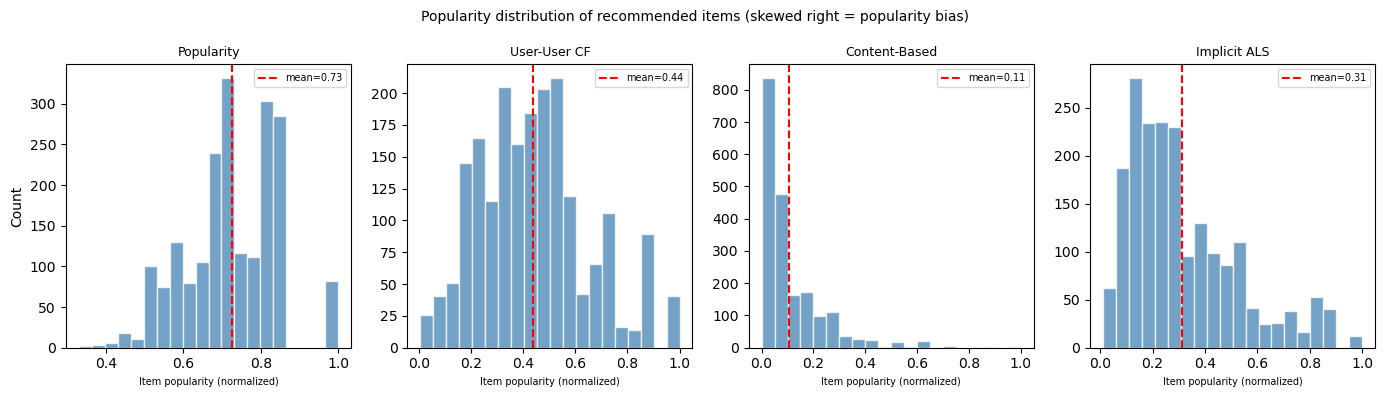

In [12]:
fig, axes = plt.subplots(1, len(model_names), figsize=(14, 4), sharey=False)

pop_norm = item_popularity / item_popularity.max()

for ax, (name, fn) in zip(axes, models):
    # Collect all recommended items across all users
    all_recommended_items = []
    for user_idx in list(test_dict.keys())[:200]:  # sample 200 users for speed
        recs = get_top_k_recommendations(fn, user_idx, k=K)
        all_recommended_items.extend(recs)
    
    pops = [pop_norm[i] for i in all_recommended_items]
    ax.hist(pops, bins=20, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Item popularity (normalized)', fontsize=7)
    if ax == axes[0]:
        ax.set_ylabel('Count')
    ax.axvline(np.mean(pops), color='red', linestyle='--', linewidth=1.5,
               label=f'mean={np.mean(pops):.2f}')
    ax.legend(fontsize=7)

fig.suptitle('Popularity distribution of recommended items (skewed right = popularity bias)', fontsize=10)
plt.tight_layout()
plt.savefig('popularity_bias.png', dpi=120, bbox_inches='tight')
plt.show()

## Metric Behavior Across K

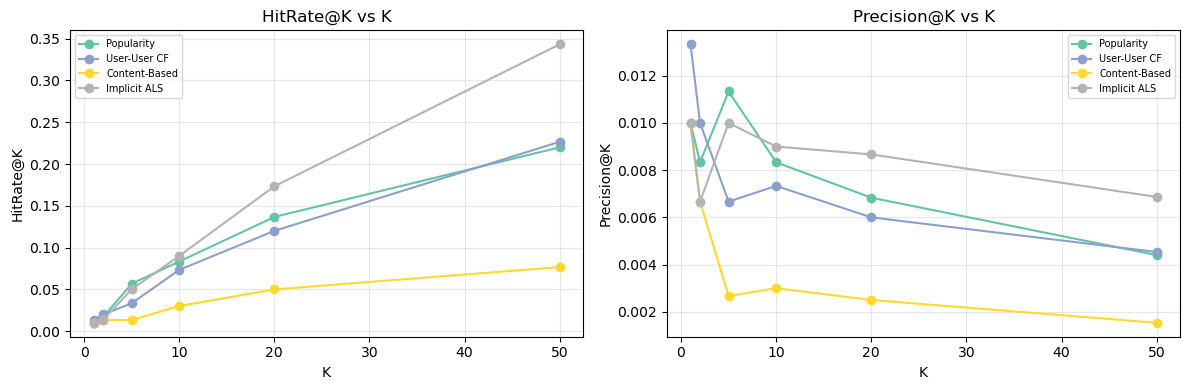

In [13]:
# How do HitRate and Precision trade off as K increases?
K_values = [1, 2, 5, 10, 20, 50]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (name, fn) in enumerate(models):
    hrs, precs = [], []
    for k in K_values:
        h_list, p_list = [], []
        for user_idx, test_item in list(test_dict.items())[:300]:  # sample for speed
            recs = get_top_k_recommendations(fn, user_idx, k)
            h_list.append(hit_rate_at_k(recs, [test_item], k))
            p_list.append(precision_at_k(recs, [test_item], k))
        hrs.append(np.mean(h_list))
        precs.append(np.mean(p_list))
    
    axes[0].plot(K_values, hrs, marker='o', label=name, color=colors[i])
    axes[1].plot(K_values, precs, marker='o', label=name, color=colors[i])

axes[0].set_title('HitRate@K vs K')
axes[0].set_xlabel('K'); axes[0].set_ylabel('HitRate@K')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].set_title('Precision@K vs K')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Precision@K')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_vs_k.png', dpi=120, bbox_inches='tight')
plt.show()

## Key Takeaways

### The accuracy-diversity tradeoff

Models with higher HitRate/NDCG tend to have **lower** catalog coverage and diversity. This is the fundamental accuracy-diversity tradeoff in RecSys:
- High-accuracy models learn that popular items are often relevant → they recommend them repeatedly
- The long tail gets neglected → users miss potentially perfect but obscure recommendations
- Catalog coverage suffers → new or niche items never get surface

### Popularity bias is endemic

The popularity bias plots show that every model — even content-based — skews its recommendations toward popular items. This happens because:
1. Training data is interaction-weighted: popular items have more ratings → more training signal
2. The test set is also popularity-biased: users are more likely to have rated popular items

Mitigation strategies: inverse propensity scoring, popularity-discounted training, diversity regularization.

### HitRate vs Precision: different questions

- **HitRate@K**: Did we surface at least one relevant item? The correct metric for "did the user find what they wanted?"
- **Precision@K**: What fraction of our list is relevant? As K grows, HitRate saturates toward 1 while precision falls (more items, same relevance budget).

For recommender system evaluation, **NDCG@K** is usually preferred: it rewards putting relevant items higher in the list, not just including them somewhere.

### MAP vs NDCG

- **MAP** (Mean Average Precision): treats all relevant items as equally important; averages precision at each recall point
- **NDCG**: weights by position using a log discount; a hit at rank 1 is worth much more than rank 10

For single-item LOO evaluation (one test item per user), MAP and NDCG give very similar results. They diverge when a user has many relevant items.

### Offline metrics lie about serendipity

The serendipity metric scores near zero for all models. This isn't because the models recommend nothing serendipitous — it's because the test set only contains items the user **already rated**. A recommendation that would delight a user with something they've never heard of can't score here.

This is the most important limitation of offline evaluation. The only way to measure serendipity is with online A/B tests and explicit user feedback.

### Next: Business Value
Section 08 closes the loop — from offline metrics to actual business outcomes. A/B test design, revenue lift calculation, and how to communicate model value to stakeholders.